In [1]:
import numpy as np
import pandas as pd

In [18]:
df=pd.read_csv('Customer/train.csv', delimiter=',')

In [19]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [67]:
x_train=df.drop(columns=['Churn', 'CustomerID'])
y_train=df['Churn']

In [21]:
y_train

0         1.0
1         1.0
2         1.0
3         1.0
4         1.0
         ... 
440828    0.0
440829    0.0
440830    0.0
440831    0.0
440832    0.0
Name: Churn, Length: 440833, dtype: float64

In [22]:
x_train.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [24]:
categorical_columns=df.select_dtypes(include='object')
numerical_columns=df.select_dtypes(include='float64')

In [42]:
categorical_columns.columns

Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')

In [28]:
categorical_columns.columns.tolist()

['Gender', 'Subscription Type', 'Contract Length']

In [29]:
y_train.nunique()

2

In [31]:
y_train.value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

In [35]:
df[numerical_columns.columns.tolist()].corr()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
CustomerID,1.000000,-0.181977,0.044129,0.038455,-0.482894,-0.262029,0.359289,-0.125356,-0.839365
Age,-0.181977,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394
Tenure,0.044129,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919
Usage Frequency,0.038455,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101
Support Calls,-0.482894,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267
Payment Delay,-0.262029,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129
Total Spend,0.359289,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355
Last Interaction,-0.125356,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616
Churn,-0.839365,0.218394,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000


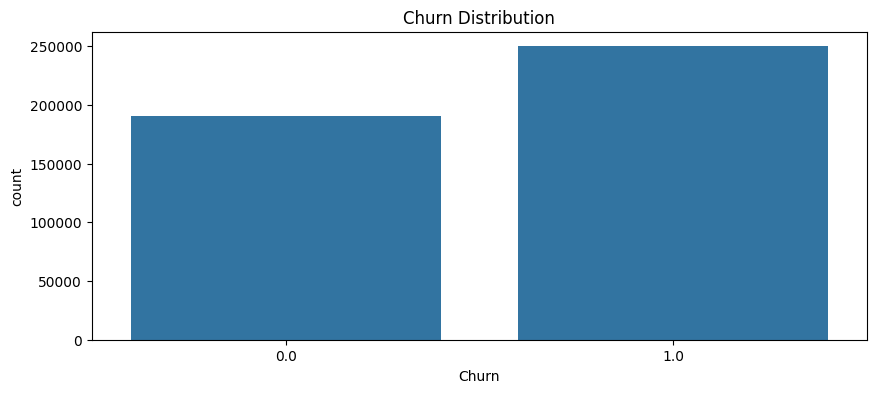

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

In [40]:
df.groupby('Gender')['Churn'].value_counts()

Gender  Churn
Female  1.0      127058
        0.0       63522
Male    0.0      127311
        1.0      122941
Name: count, dtype: int64

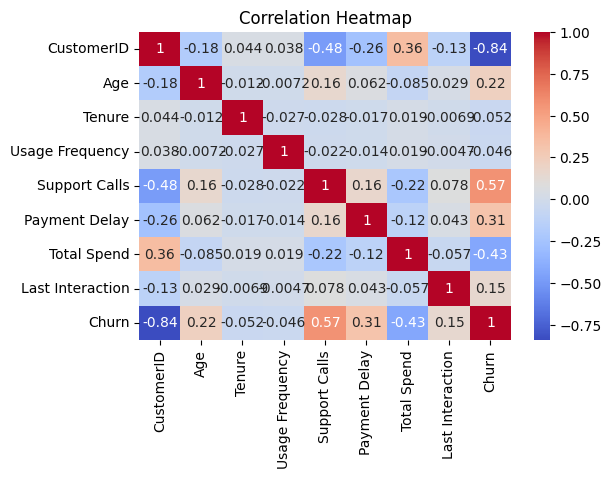

In [44]:
plt.figure(figsize=(6,4))
sns.heatmap(df[numerical_columns.columns.tolist()].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [49]:
#Data Cleaning

df=df.dropna()

In [50]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [55]:
df.drop('CustomerID', axis=1)

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [56]:
df_test=pd.read_csv('Customer/test.csv', delimiter=',')

In [58]:
df_test.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [60]:
df_test=df_test.drop('CustomerID', axis=1)

In [62]:
x_test=df_test.drop('Churn', axis=1)
y_test=df_test['Churn']

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

x_train=pd.get_dummies(x_train, drop_first=True).astype(int)
x_test=pd.get_dummies(x_test, drop_first=True ).astype(int)


In [69]:
x_train

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30,39,14,5,18,932,17,0,0,1,0,0
1,65,49,1,10,8,557,6,0,0,0,1,0
2,55,14,4,6,18,185,3,0,0,0,0,1
3,58,38,21,7,7,396,29,1,0,1,1,0
4,23,32,20,5,8,617,20,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,42,54,15,1,3,716,8,1,1,0,0,0
440829,25,8,13,1,20,745,2,0,1,0,0,0
440830,26,35,27,1,5,977,9,1,0,1,0,1
440831,28,55,14,2,0,602,2,1,0,1,0,1


In [70]:
x_test

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,0,0,0,1,0
1,41,28,28,7,13,584,20,0,0,1,1,0
2,47,27,10,2,29,757,21,1,1,0,0,0
3,35,9,12,5,17,232,18,1,1,0,0,1
4,53,58,24,9,2,533,18,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,45,33,12,6,21,947,14,0,0,0,0,1
64370,37,6,1,5,22,923,9,1,0,1,0,0
64371,25,39,14,8,30,327,20,1,1,0,1,0
64372,50,18,19,7,22,540,13,0,0,1,1,0


In [74]:
y_train=y_train.astype(int)
y_test=y_test.astype(int)

In [73]:
y_train

0         1
1         1
2         1
3         1
4         1
         ..
440828    0
440829    0
440830    0
440831    0
440832    0
Name: Churn, Length: 440832, dtype: int64

In [78]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [79]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier()
knn.fit(x_train_scaled, y_train)
y_pred=knn.predict(x_test_scaled)

In [80]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_score(y_test, y_pred)

0.5390219653897537

In [81]:
confusion_matrix(y_test, y_pred)

array([[ 4612, 29269],
       [  406, 30087]])

In [82]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.14      0.24     33881
           1       0.51      0.99      0.67     30493

    accuracy                           0.54     64374
   macro avg       0.71      0.56      0.45     64374
weighted avg       0.72      0.54      0.44     64374



In [84]:
k_values=[1,3,5,7,10]
accs=[]
for k in k_values:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_scaled, y_train)
    preds=model.predict(x_test_scaled)
    acc=accuracy_score(y_test, preds)
    accs.append(acc)

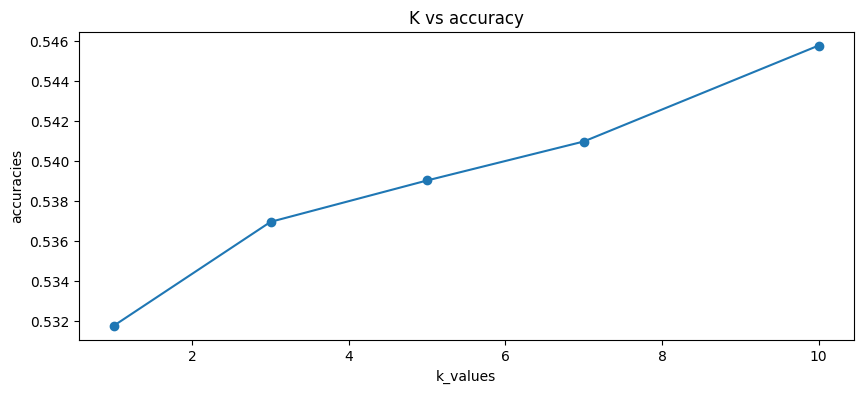

In [85]:
plt.figure(figsize=(10,4))
plt.plot(k_values, accs, marker='o')
plt.xlabel('k_values')
plt.ylabel('accuracies')
plt.title('K vs accuracy')
plt.show()

In [86]:
best_k=k_values[np.argmax(accs)]
best_k

10

In [87]:
from sklearn.model_selection import cross_val_score

cv_values=cross_val_score(
    KNeighborsClassifier(n_neighbors=best_k),
    x_train_scaled, y_train, cv=5
)
cv_values.mean()

np.float64(0.9526372894188961)

In [89]:
metrics=['euclidean', 'manhattan', 'minkowski']
for metric in metrics:
    model=KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    model.fit(x_train_scaled, y_train)
    pred=model.predict(x_test_scaled)
    acc=accuracy_score(y_test, pred)
    print(f'{metric.capitalize()} Accuracy: {acc}')

Euclidean Accuracy: 0.545748283468481
Manhattan Accuracy: 0.5497405784944233
Minkowski Accuracy: 0.545748283468481
